<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Student%20Mental%20Health%20%26%20Burnout%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Mental Health and Burnout Dataset


## Understanding Student Mental Health and Social Media Impact

The dataset at hand provides a comprehensive look into the lives of students, focusing on their mental health, academic performance, and the pervasive influence of social media. Comprising 1705 entries across 11 features, it delves into various aspects including student demographics (age, gender, academic level, country), social media usage (average daily hours, most used platform), and crucial indicators like sleep hours, mental health scores, and perceived academic and overall life impact. The dataset is remarkably clean, with no missing values or duplicates, ensuring reliable analysis from the outset.

Our initial exploration revealed several key patterns. Most students fall within the 18-24 age bracket, with a fairly even distribution between genders and a majority being undergraduates. Instagram, TikTok, and Facebook emerge as the most popular social media platforms. Concerning impact, a significant portion of students (over 59%) reported that social media negatively affects their overall life, and an even larger number (nearly 60%) believe it negatively impacts their academic performance.

To dig deeper into the potential for burnout, we engineered two critical metrics: 'Sleep_Deficit' (quantifying hours below a healthy 8-hour sleep baseline) and 'Digital_Saturation_Ratio' (comparing screen time to sleep time). These metrics were instrumental in uncovering profound insights:

Key Insights Revealed:

Platform Toxicity: A Kruskal-Wallis test revealed a statistically significant variance in mental health scores based on the Most_Used_Platform. This suggests that the design and algorithmic features of specific social media platforms can indeed impose a heavier psychological toll on students. Not all platforms are equally benign or detrimental.

The Burnout Tipping Point: A robust negative correlation was found between Digital_Saturation_Ratio and Mental_Health_Score (Spearman coefficient: -0.8652). This is a stark finding: as students spend more time scrolling than sleeping, their cognitive resilience and mental well-being statistically collapse. The

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d abrerjawod/student-mental-health-and-burnout-dataset

# Unziping the downloaded file
!unzip student-mental-health-and-burnout-dataset.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/abrerjawod/student-mental-health-and-burnout-dataset
License(s): MIT
100% 18.2k/18.2k [00:00<00:00, 20.7MB/s]

Archive:  student-mental-health-and-burnout-dataset.zip
  inflating: Social_media_impact_on_life.csv  


In [4]:
df = pd.read_csv('Social_media_impact_on_life.csv')
df.head(11)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
5,370,19,Female,High School,Other,4.1,Twitter,Yes,6.8,6.8,Neutral
6,862,22,Female,Graduate,Other,8.0,Instagram,Yes,5.2,5.3,Negative
7,520,21,Female,Graduate,Other,6.0,Facebook,Yes,5.7,4.7,Negative
8,703,24,Male,Undergraduate,USA,4.7,YouTube,No,7.0,6.2,Neutral
9,33,19,Male,High School,Other,3.6,TikTok,No,8.1,8.6,Positive


In [5]:
df.tail(11)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
1694,695,20,Female,Undergraduate,Turkey,6.6,Instagram,Yes,6.1,5.0,Negative
1695,696,23,Male,Graduate,USA,5.5,Twitter,Yes,6.7,6.0,Negative
1696,697,21,Female,Undergraduate,Mexico,6.3,TikTok,Yes,6.2,5.0,Negative
1697,698,24,Male,Graduate,France,4.8,Facebook,No,7.1,7.0,Positive
1698,699,19,Female,Undergraduate,Canada,5.7,Instagram,Yes,6.6,6.0,Negative
1699,700,22,Male,Graduate,UK,6.2,Twitter,Yes,6.3,5.0,Negative
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive


In [6]:
df.shape

(1705, 11)

In [7]:
df.dtypes

,0
Student_ID,int64
Age,int64
Gender,object
Academic_Level,object
Country,object
Avg_Daily_Usage_Hours,float64
Most_Used_Platform,object
Affects_Academic_Performance,object
Sleep_Hours_Per_Night,float64
Mental_Health_Score,float64


In [8]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,1705.0,NaN,NaN,NaN,439.510264,267.058174,1.0,214.0,427.0,640.0,1000.0
Age,1705.0,NaN,NaN,NaN,20.848094,1.758557,18.0,19.0,21.0,22.0,24.0
Gender,1705,2,Male,878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic_Level,1705,3,Undergraduate,721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1705,111,Other,667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg_Daily_Usage_Hours,1705.0,NaN,NaN,NaN,5.103636,1.677341,1.5,3.8,5.1,6.3,8.5
Most_Used_Platform,1705,12,Instagram,389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Affects_Academic_Performance,1705,2,Yes,1011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours_Per_Night,1705.0,NaN,NaN,NaN,6.59871,1.207045,3.8,5.6,6.6,7.5,9.6
Mental_Health_Score,1705.0,NaN,NaN,NaN,6.215132,1.282678,4.0,5.0,6.0,7.0,9.0


In [11]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

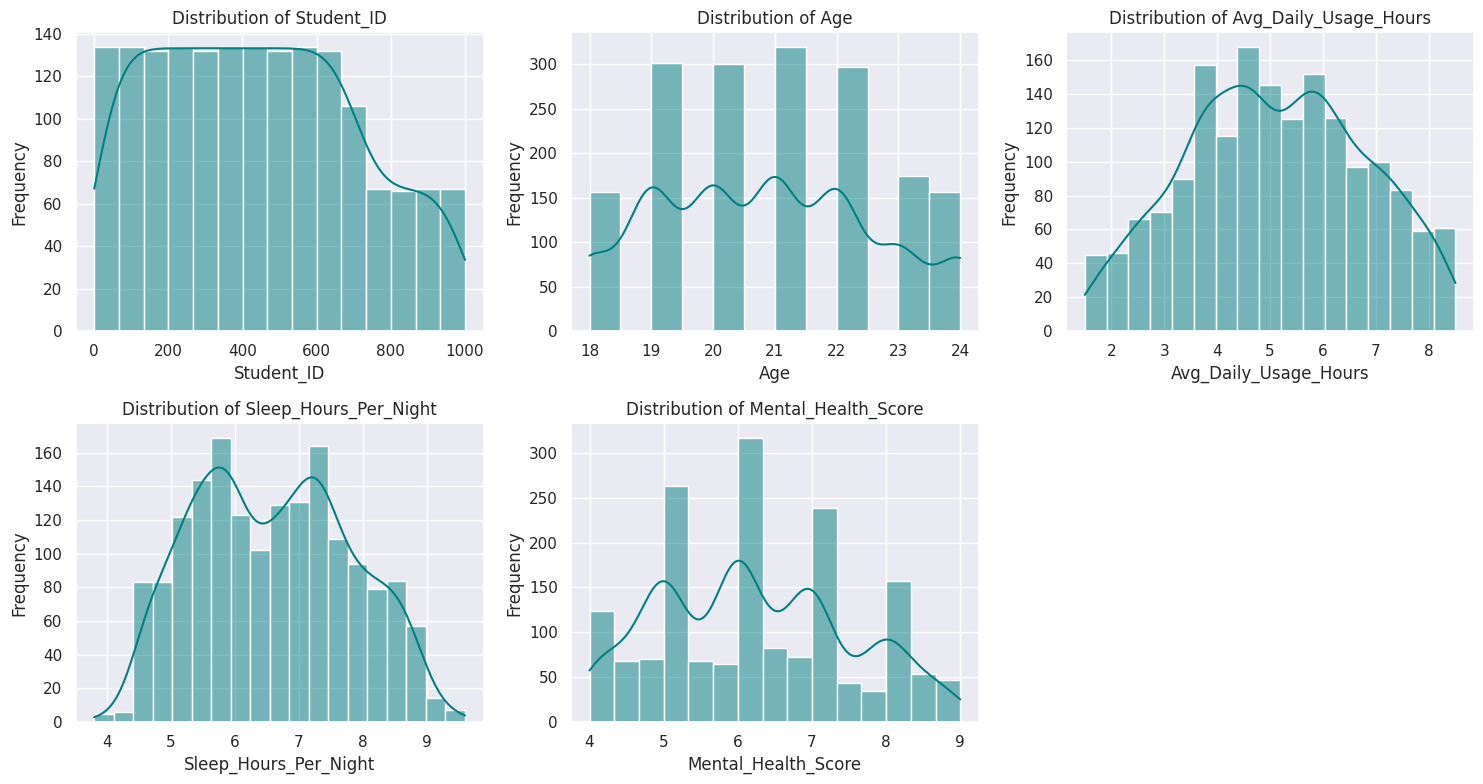

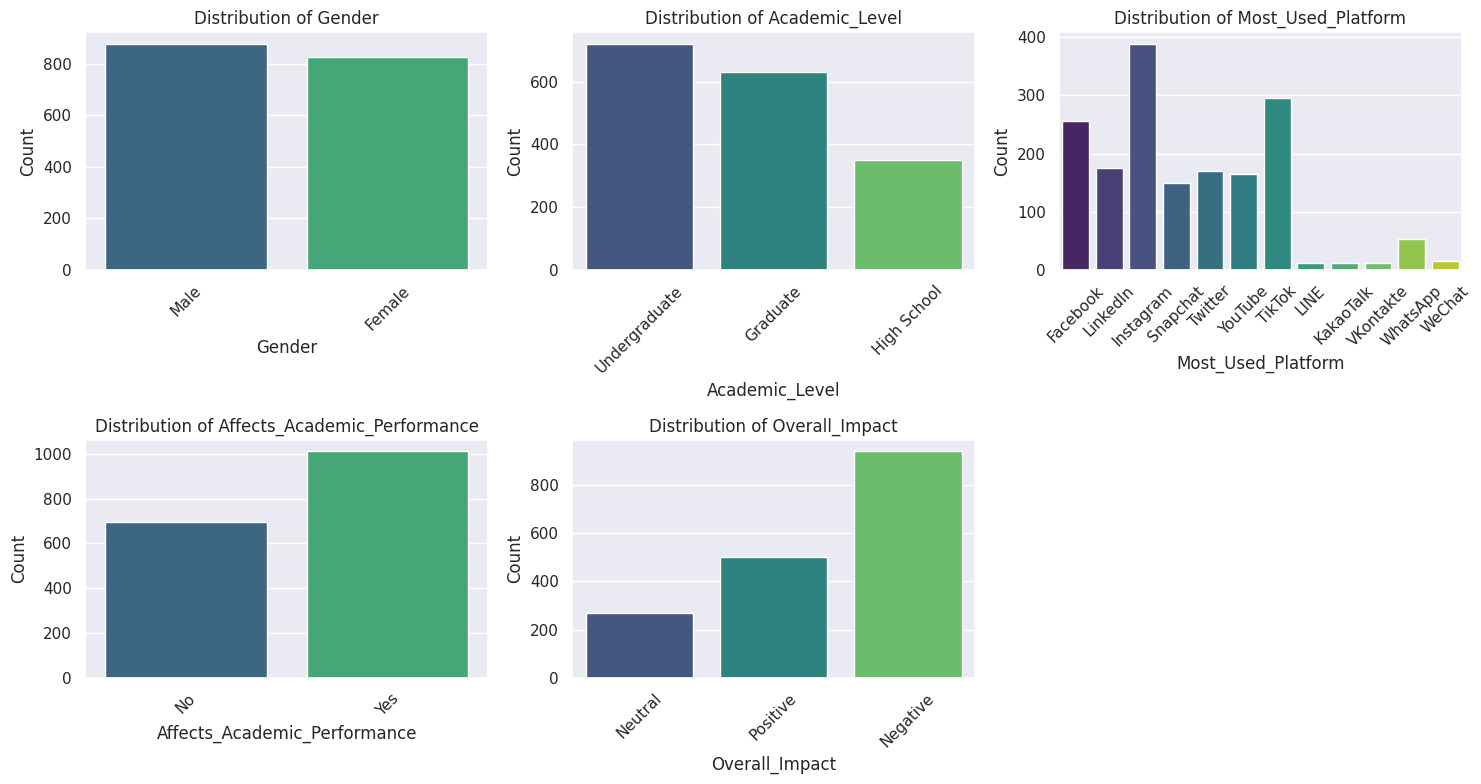

--- Categorical Value Counts ---

Value counts for Gender:
Gender
Male      878
Female    827
Name: count, dtype: int64

Value counts for Academic_Level:
Academic_Level
Undergraduate    721
Graduate         632
High School      352
Name: count, dtype: int64

Value counts for Most_Used_Platform:
Most_Used_Platform
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
VKontakte     12
KakaoTalk     12
Name: count, dtype: int64

Value counts for Affects_Academic_Performance:
Affects_Academic_Performance
Yes    1011
No      694
Name: count, dtype: int64

Value counts for Overall_Impact:
Overall_Impact
Negative    939
Positive    499
Neutral     267
Name: count, dtype: int64


In [13]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

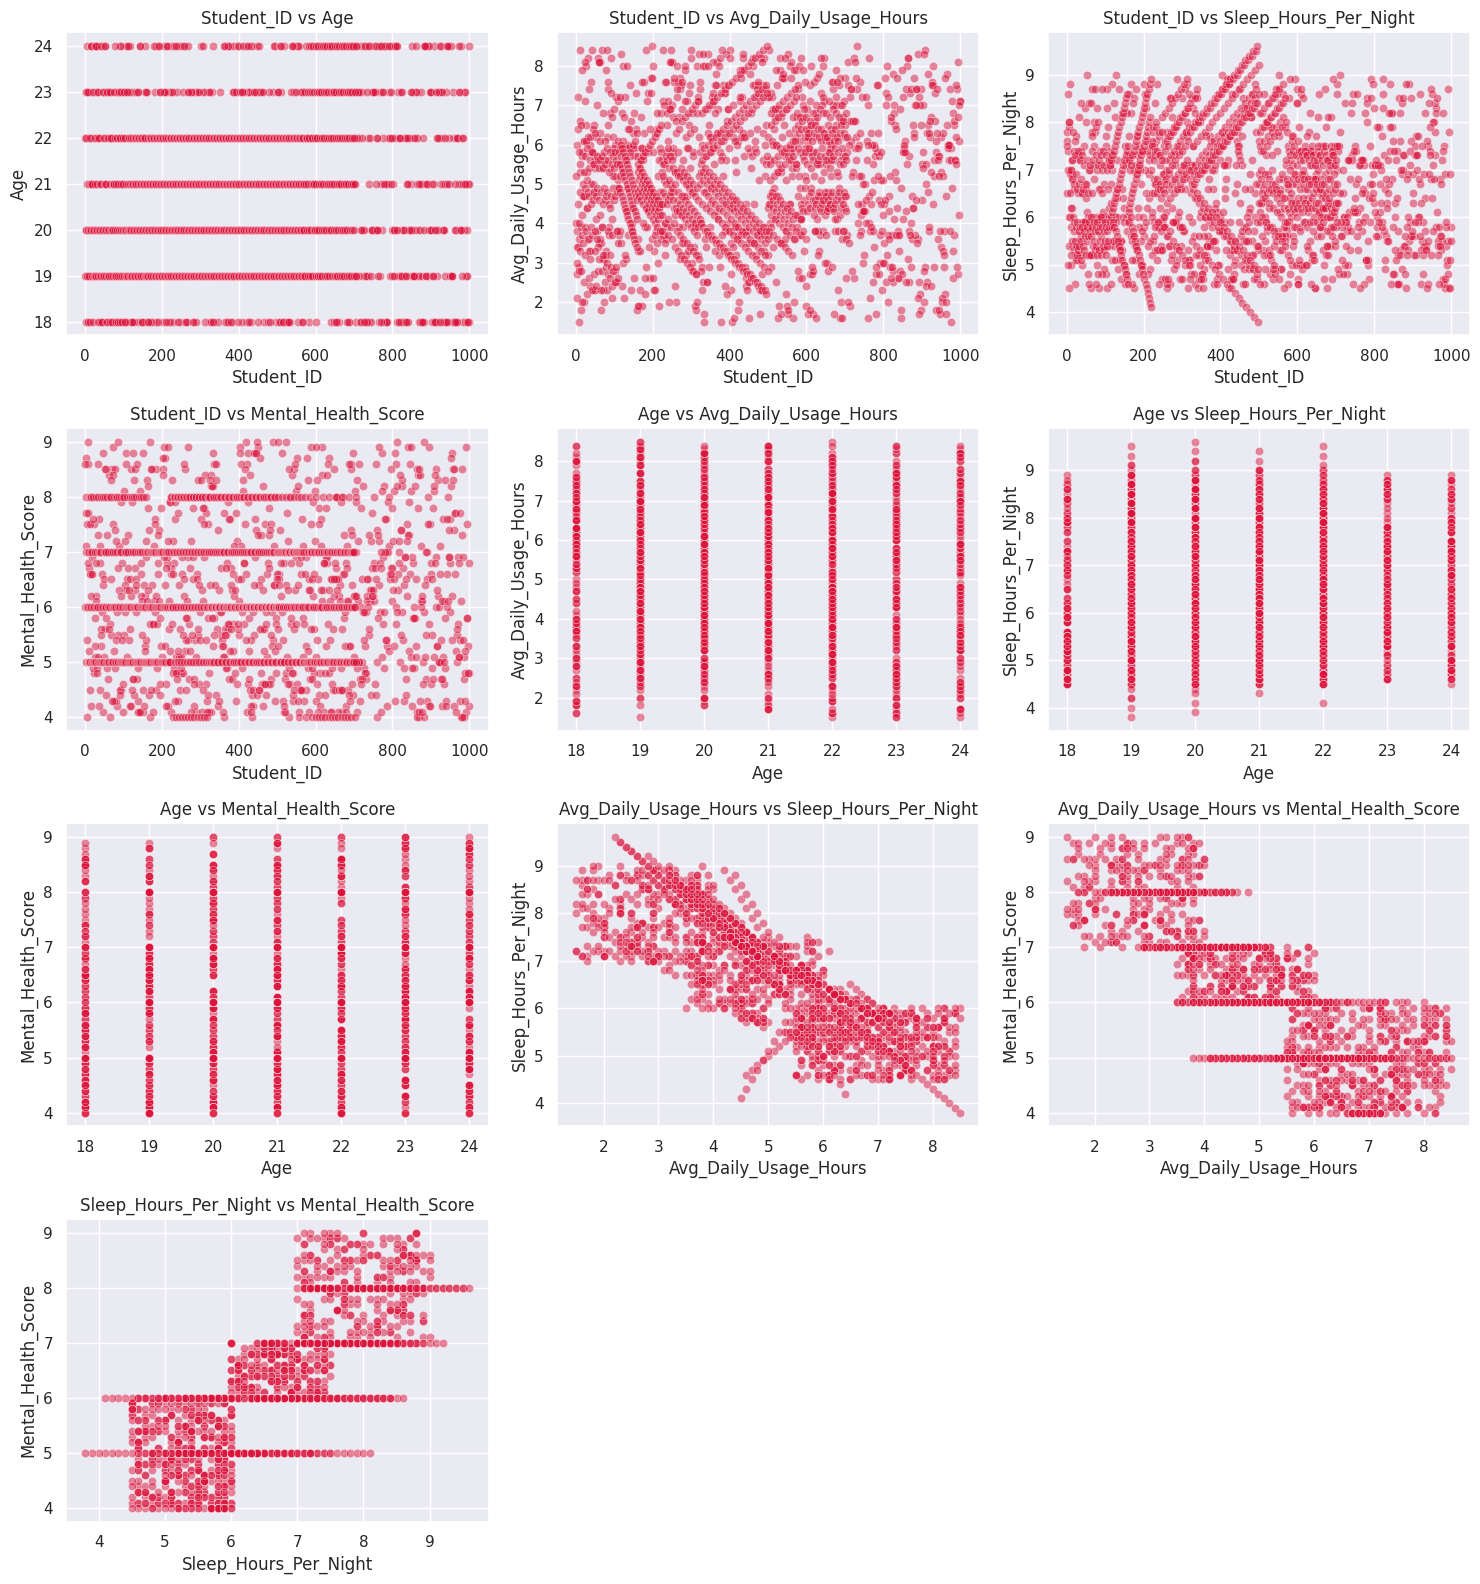

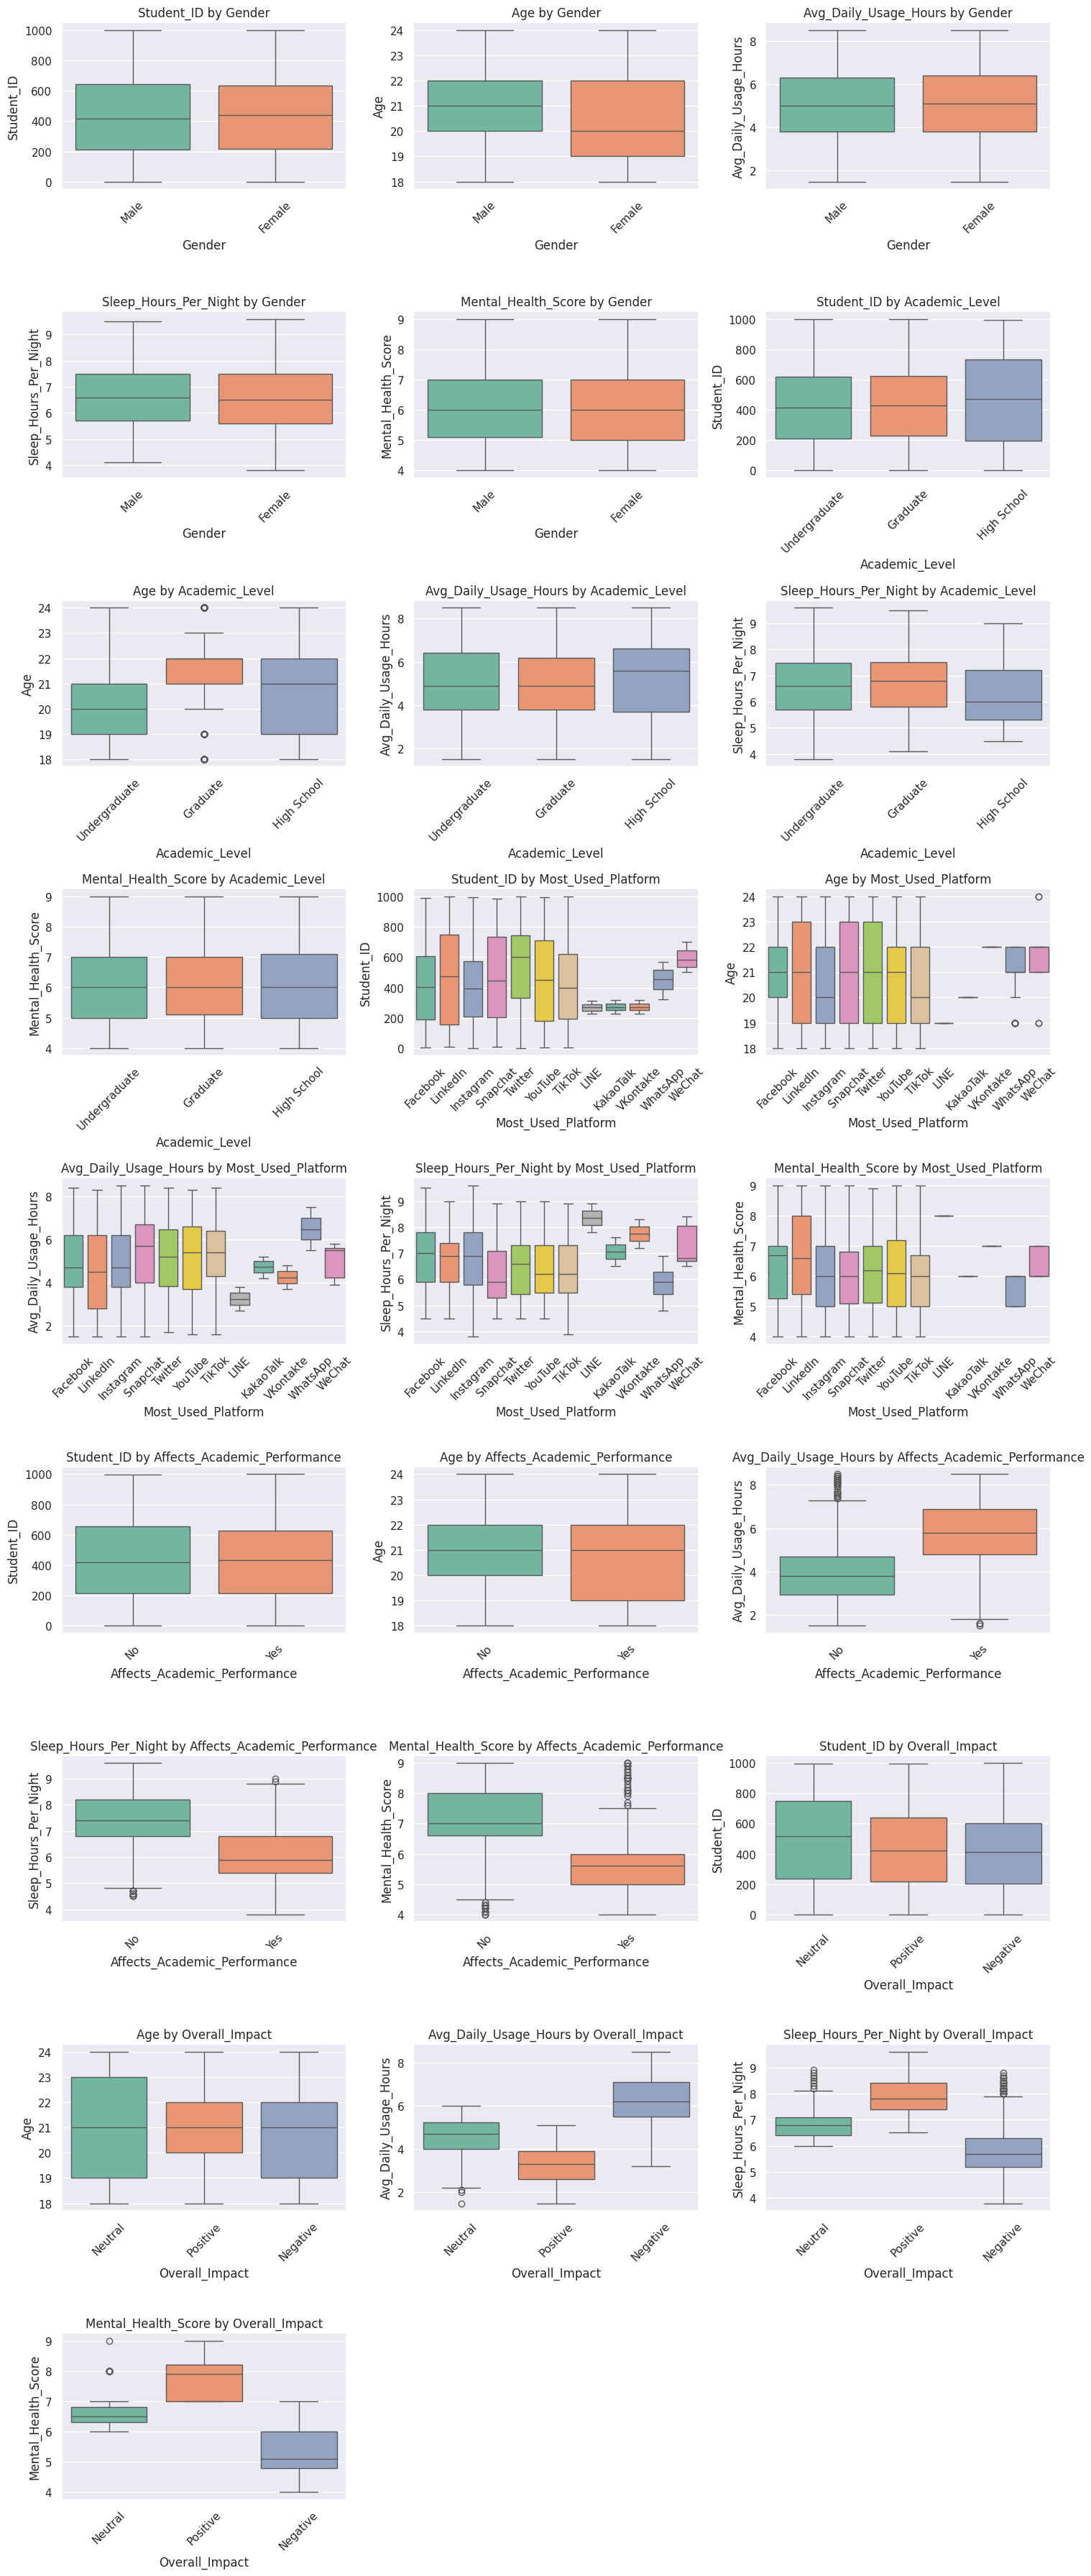

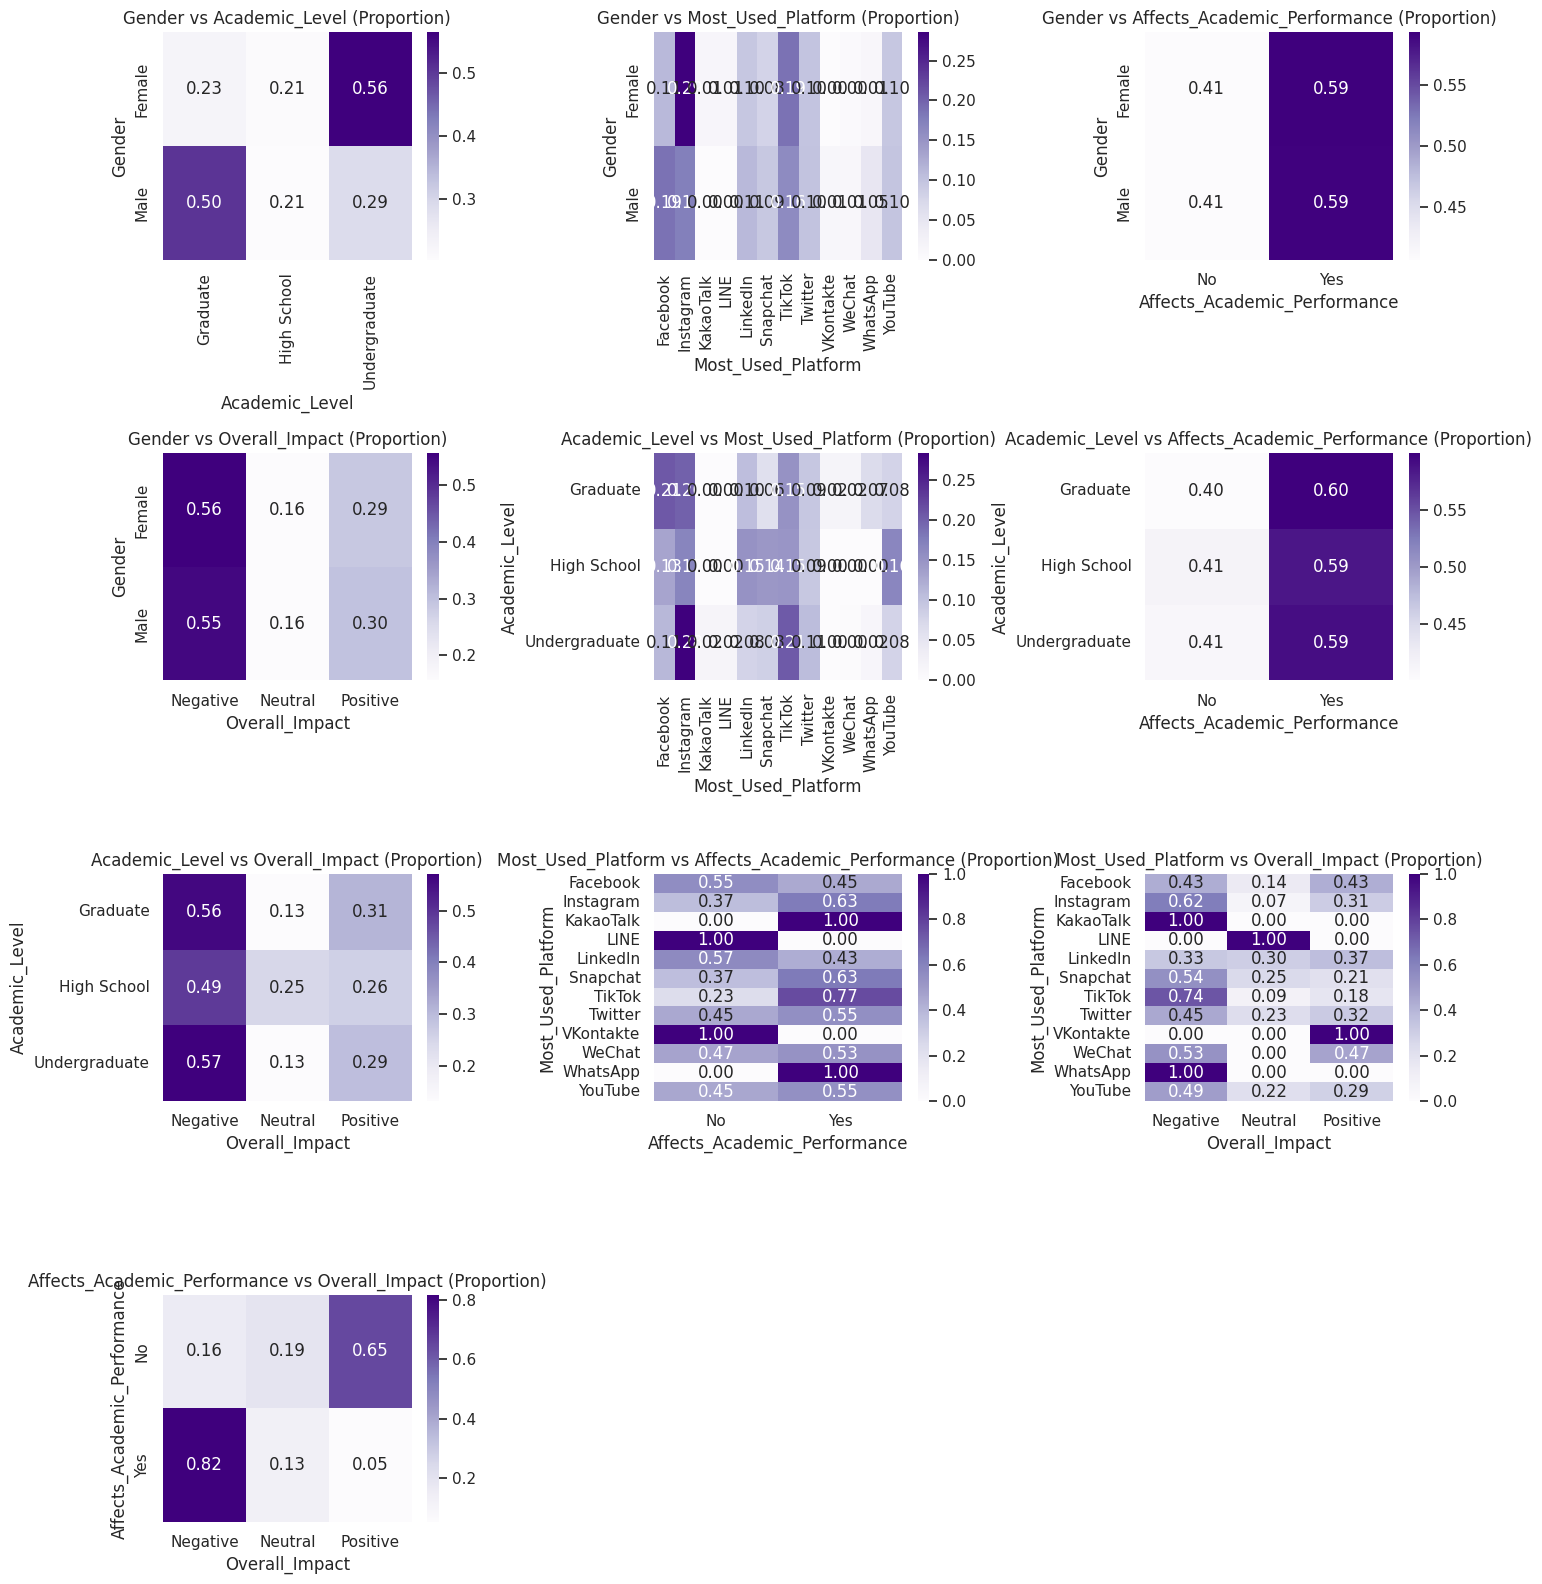

In [14]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: Gender...


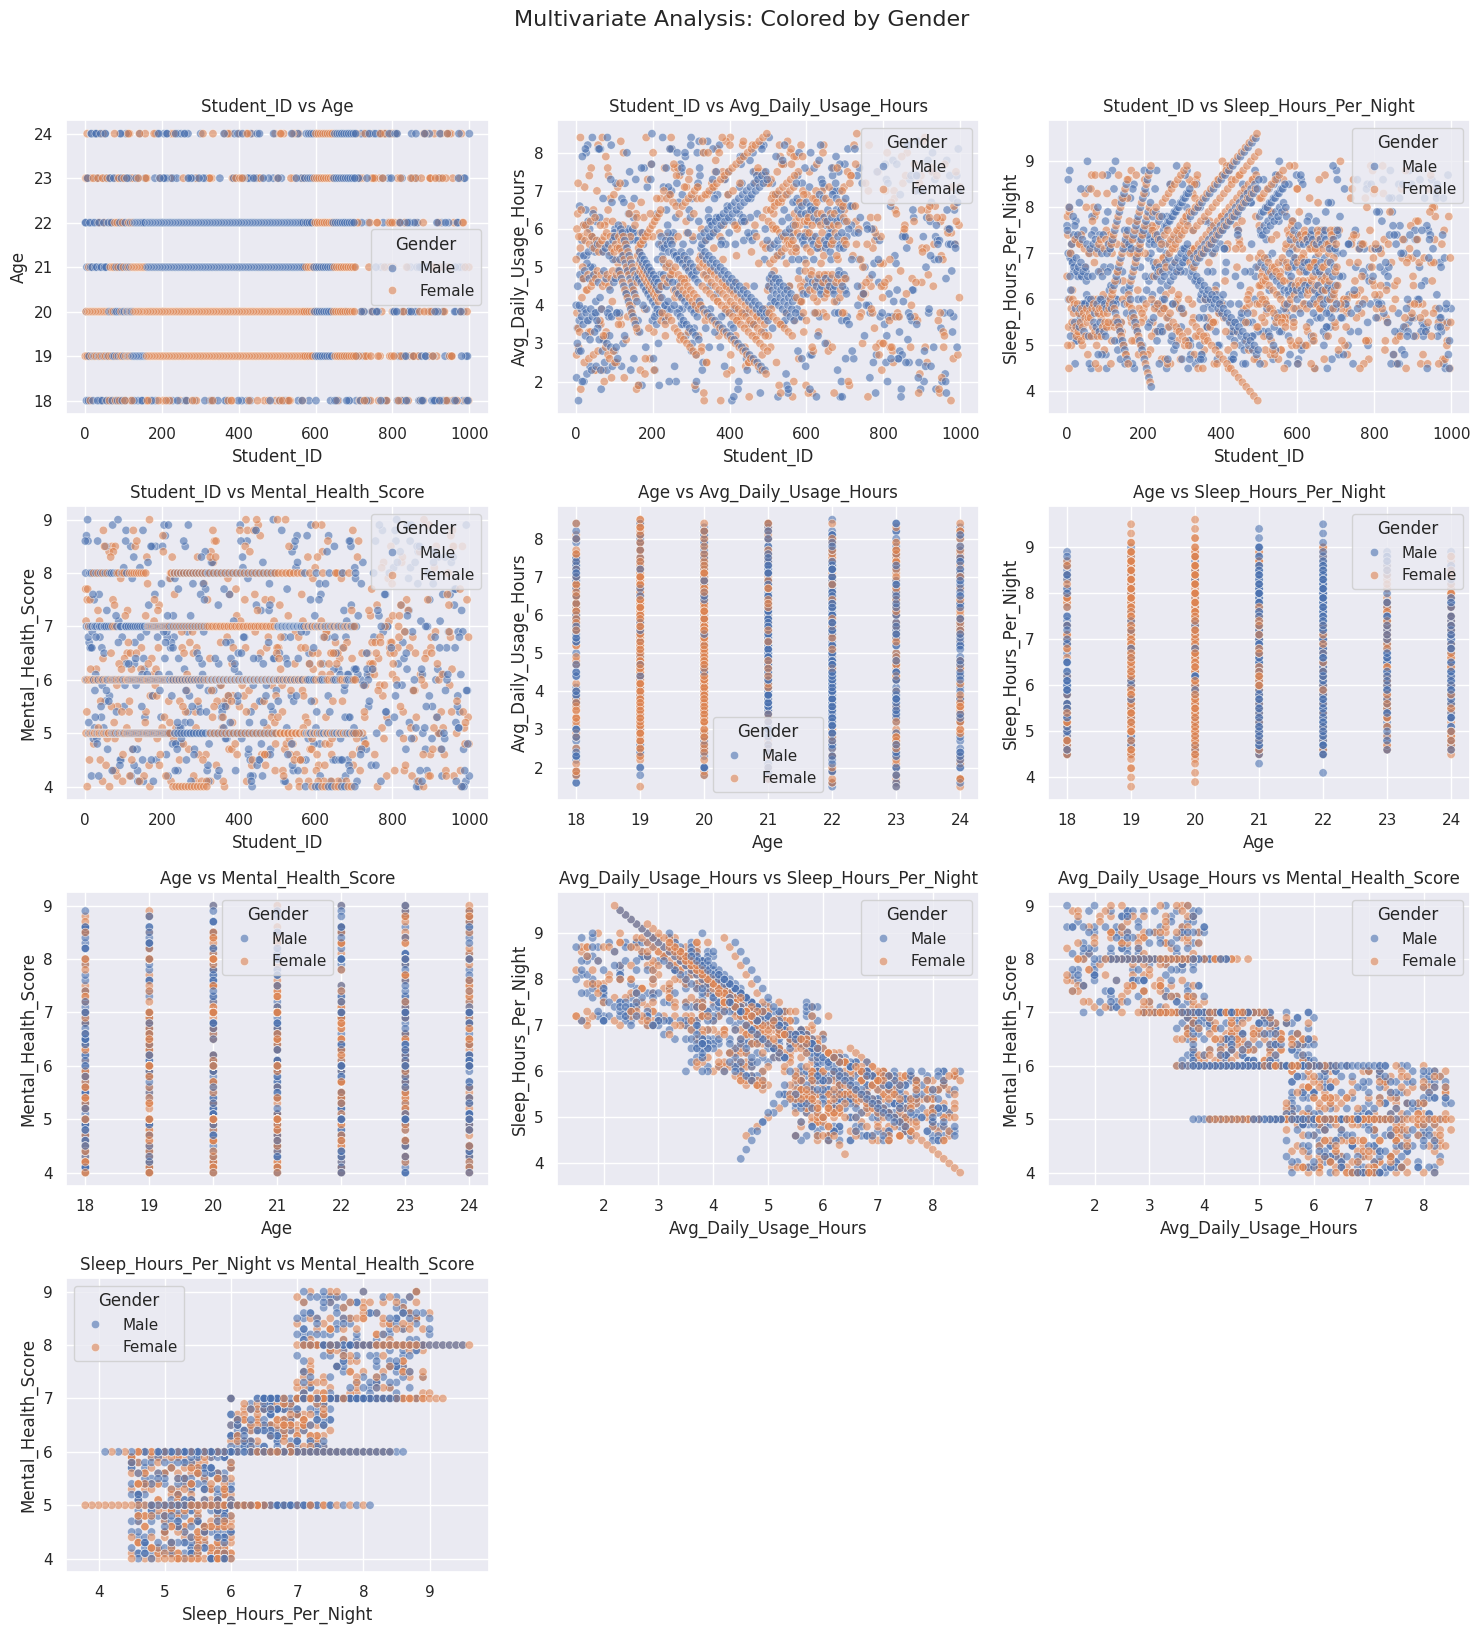


Analyzing relationships with Hue: Academic_Level...


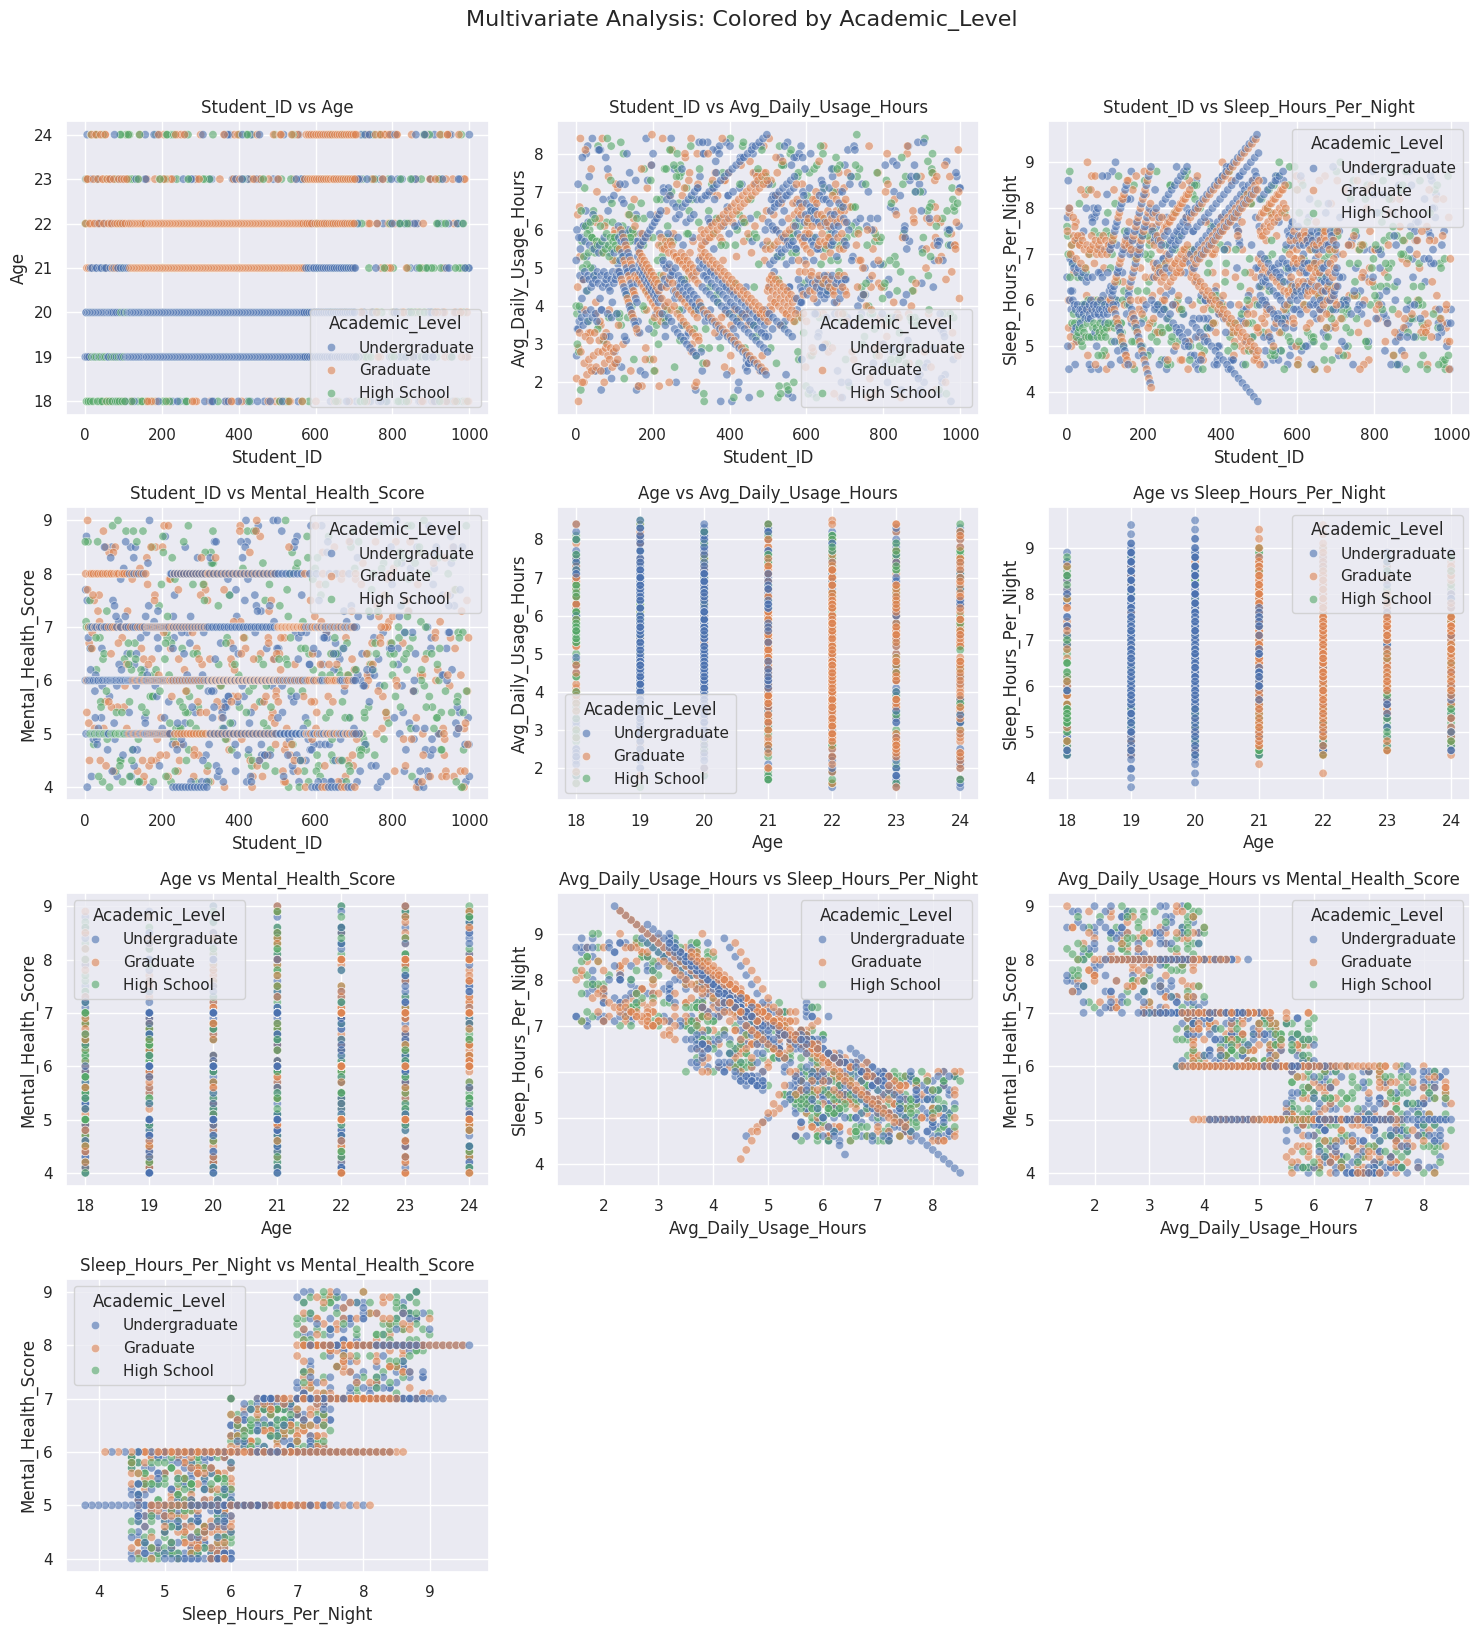


Analyzing relationships with Hue: Affects_Academic_Performance...


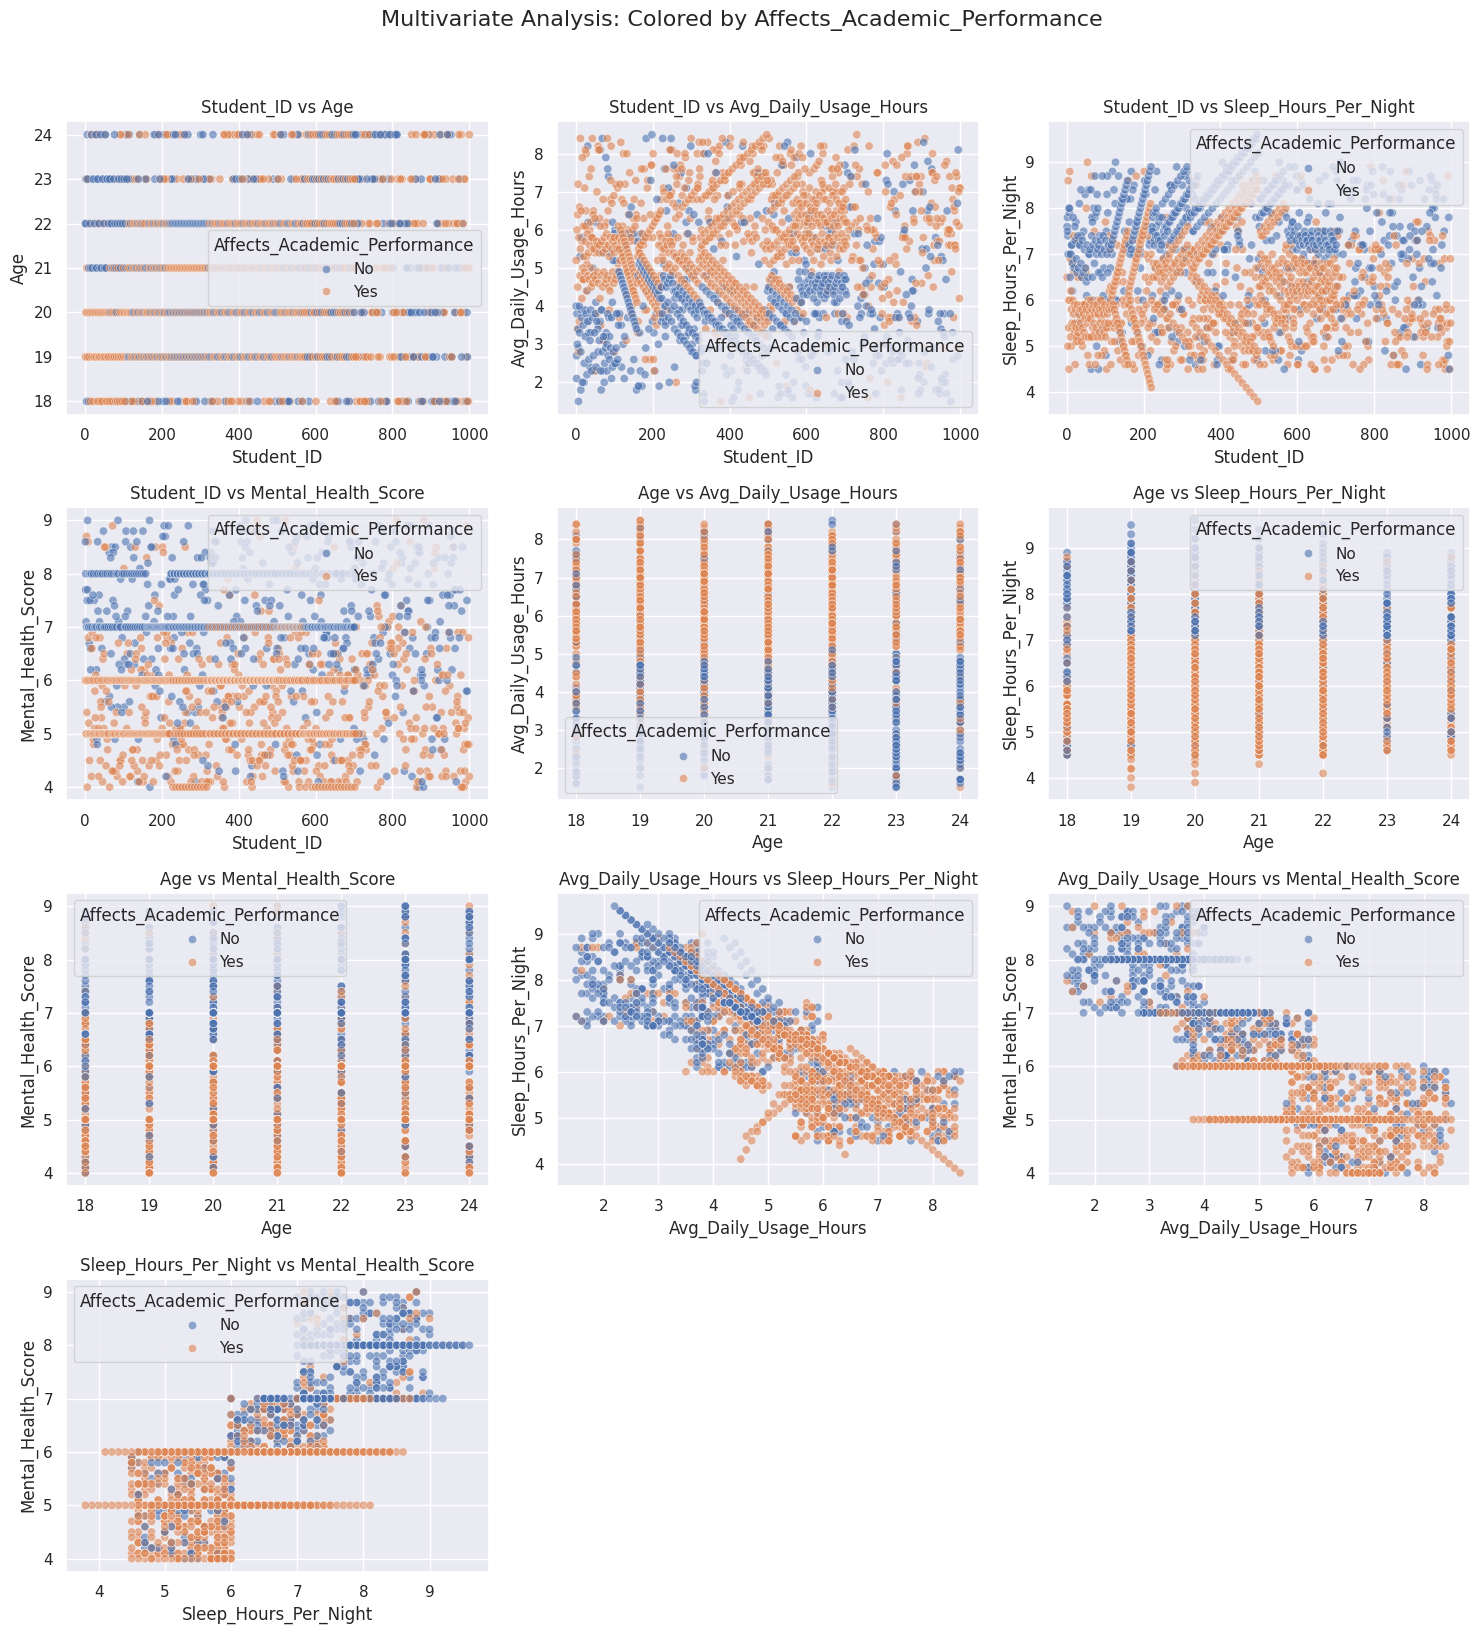


Analyzing relationships with Hue: Overall_Impact...


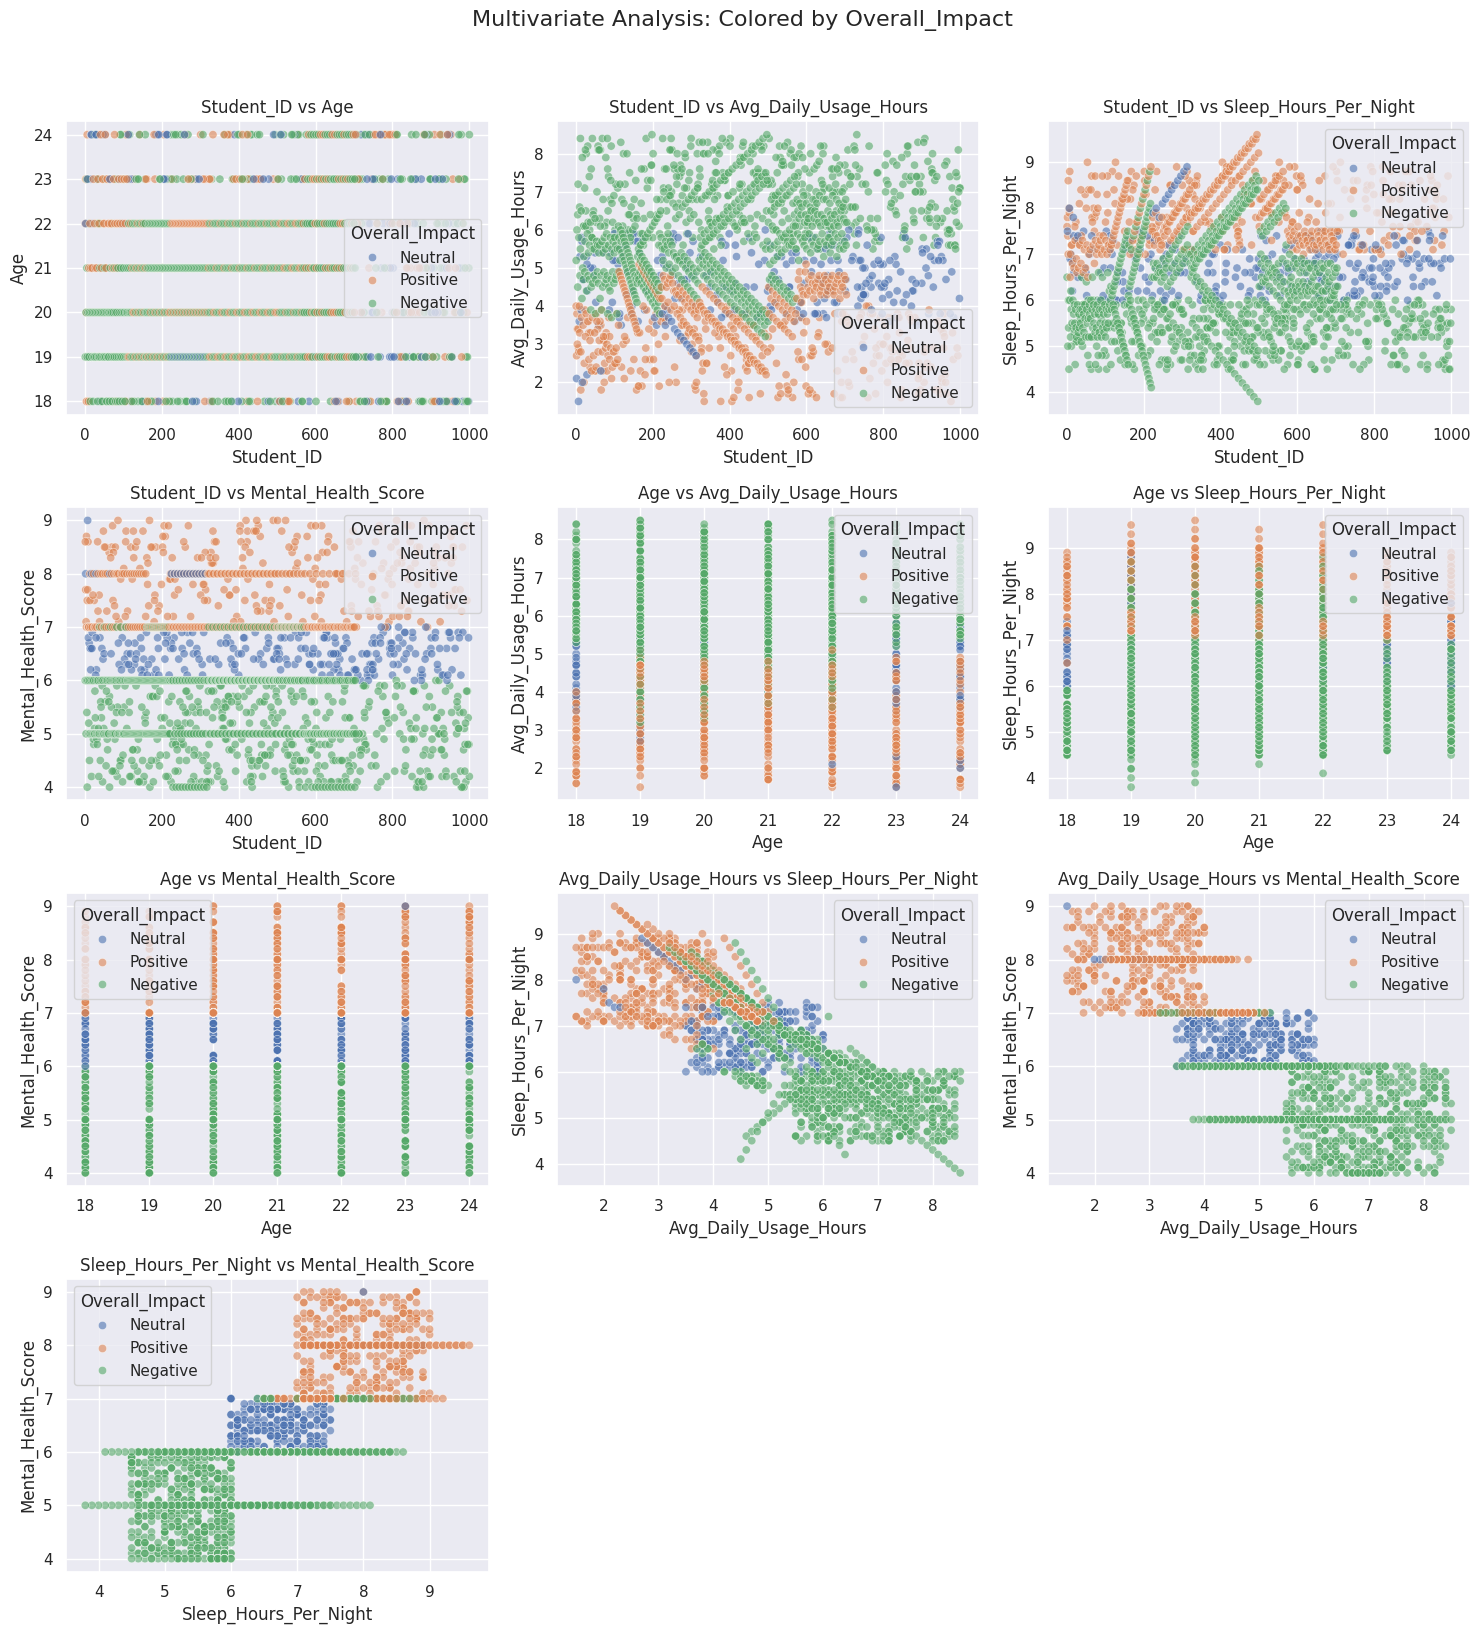

In [15]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

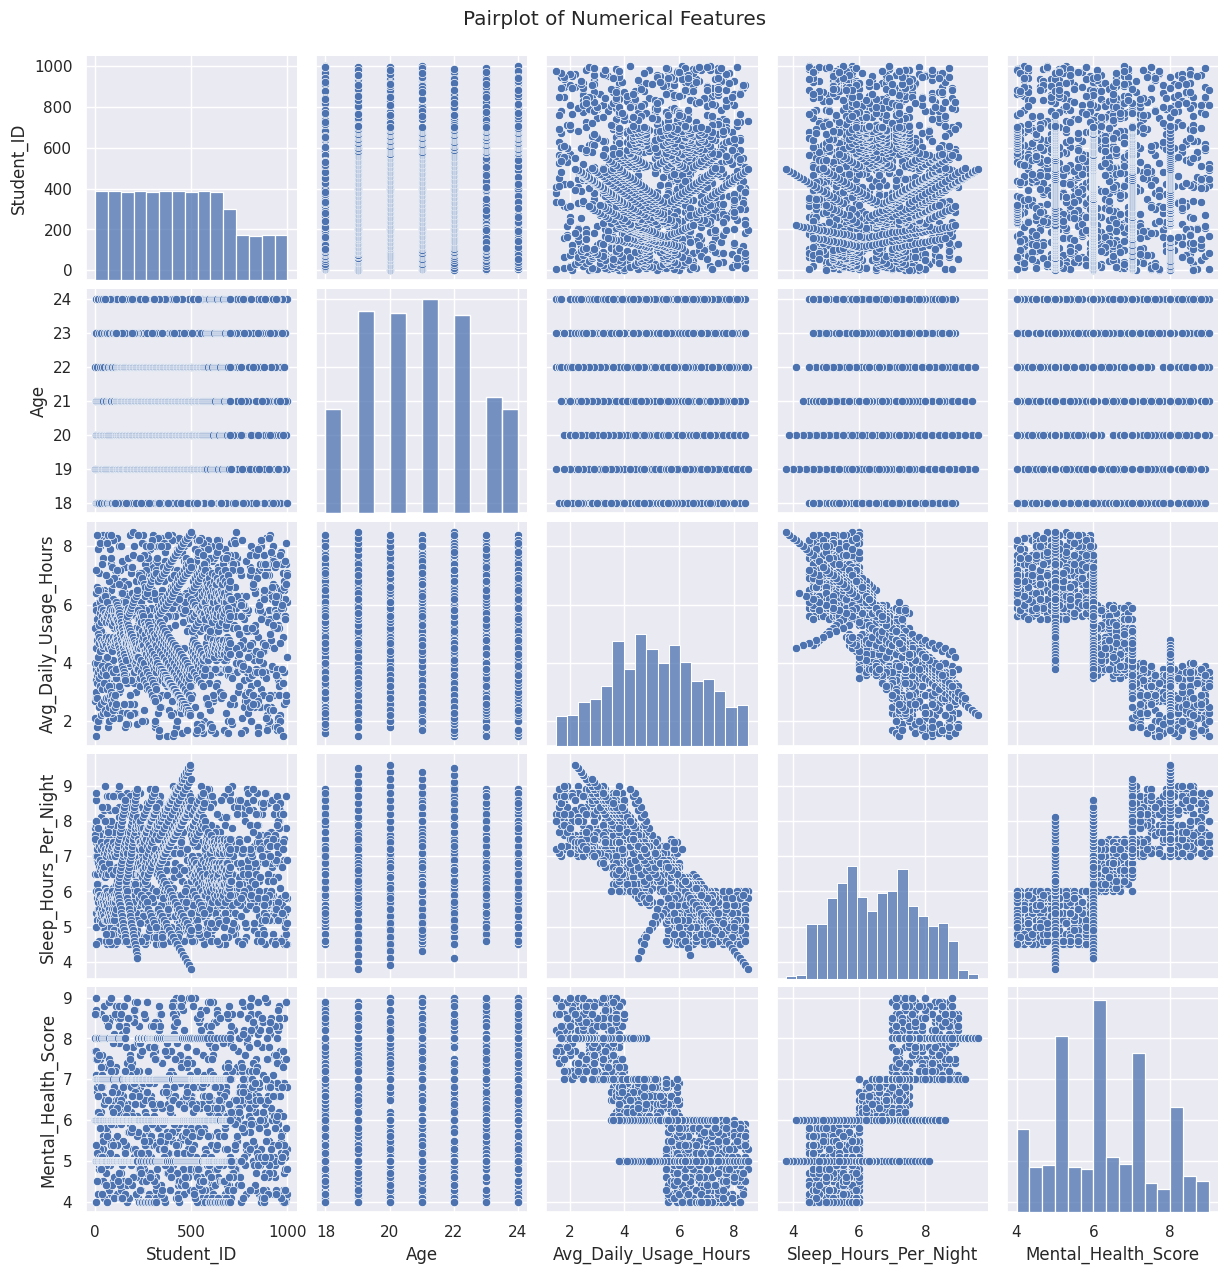

In [16]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

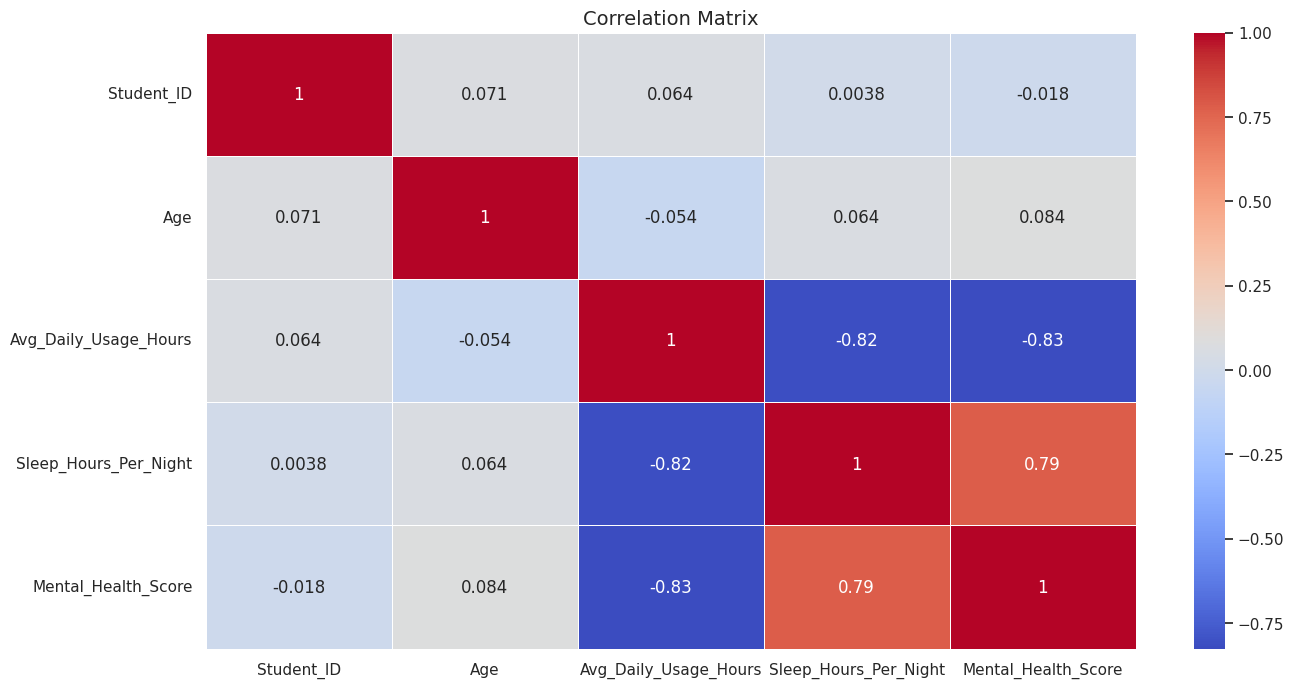

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING BEHAVIORAL METRICS ---
✅ Engineered: 'Sleep_Deficit' and 'Digital_Saturation_Ratio' to map cognitive overload.

--- 2. THE PLATFORM TOXICITY HYPOTHESIS (KRUSKAL-WALLIS H-TEST) ---
Kruskal-Wallis P-Value (Platform Toxicity Variance): 6.4040e-14
🚨 Insight: Statistically significant variance in Mental Health based on Platform.
   -> The UX/Algorithm of specific platforms mathematically induces a heavier psychological toll.


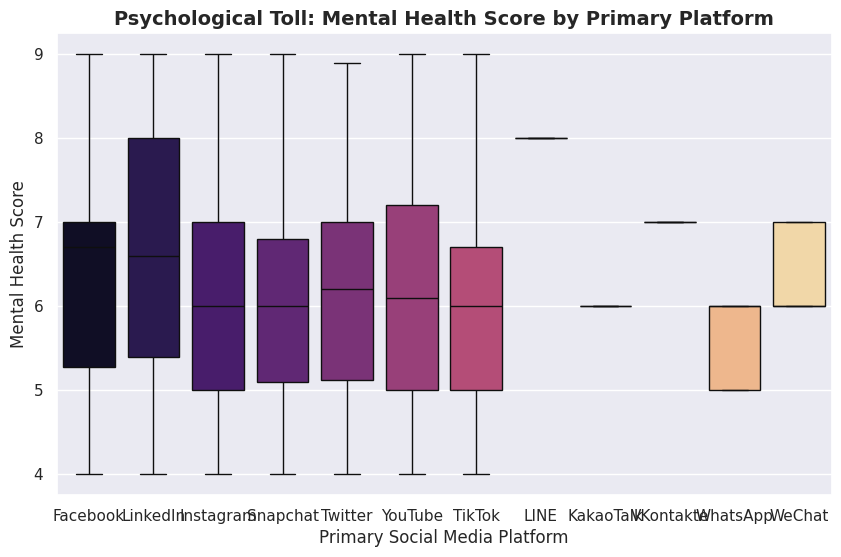


--- 3. THE BURNOUT TIPPING POINT (SPEARMAN RANK CORRELATION) ---
Spearman Correlation Coefficient (Saturation vs. Mental Health): -0.8652
P-Value: 0.0000e+00
🚨 Insight: Negative correlation validated. The 'Scrolling Paradigm' is mathematically destructive.
   -> As screen-time overtakes sleep-time, cognitive resilience statistically collapses.


In [18]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. ENGINEERING BEHAVIORAL METRICS ---")
# To analyze burnout, we must engineer metrics that reflect physical and mental exhaustion.
df_clean = df.dropna(subset=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Overall_Impact']).copy()

# 1. Cognitive Deficit Score (Negative values mean severe sleep deprivation based on an 8-hour healthy baseline)
df_clean['Sleep_Deficit'] = df_clean['Sleep_Hours_Per_Night'] - 8.0

# 2. Digital Saturation Ratio (Screen hours vs Sleep hours)
# A ratio > 1 means they spend more time scrolling than sleeping.
df_clean['Digital_Saturation_Ratio'] = df_clean['Avg_Daily_Usage_Hours'] / df_clean['Sleep_Hours_Per_Night'].replace(0, 0.1)

print("✅ Engineered: 'Sleep_Deficit' and 'Digital_Saturation_Ratio' to map cognitive overload.")


print("\n--- 2. THE PLATFORM TOXICITY HYPOTHESIS (KRUSKAL-WALLIS H-TEST) ---")
# Hypothesis: Does the specific platform choice structurally dictate a lower Mental Health Score?
# We use Kruskal-Wallis because psychological survey scores often violate normal Gaussian assumptions (heavy skew).

if 'Most_Used_Platform' in df_clean.columns:
    platforms = df_clean['Most_Used_Platform'].dropna().unique()
    platform_groups = [df_clean[df_clean['Most_Used_Platform'] == p]['Mental_Health_Score'].dropna() for p in platforms]

    if len(platform_groups) > 1:
        h_stat, p_val_kw = stats.kruskal(*platform_groups)

        print(f"Kruskal-Wallis P-Value (Platform Toxicity Variance): {p_val_kw:.4e}")
        if p_val_kw < 0.05:
            print("🚨 Insight: Statistically significant variance in Mental Health based on Platform.")
            print("   -> The UX/Algorithm of specific platforms mathematically induces a heavier psychological toll.")
        else:
            print("❌ Insight: Platform Agnostic. All social networks yield the same baseline of mental degradation.")

        # Visualize the Platform Toxicity
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Most_Used_Platform', y='Mental_Health_Score', data=df_clean, palette='magma')
        plt.title('Psychological Toll: Mental Health Score by Primary Platform', fontsize=14, fontweight='bold')
        plt.xlabel('Primary Social Media Platform')
        plt.ylabel('Mental Health Score')
        plt.show()


print("\n--- 3. THE BURNOUT TIPPING POINT (SPEARMAN RANK CORRELATION) ---")
# Hypothesis: Does increasing Digital Saturation rigorously correlate with crashing Mental Health?

spearman_coef, p_val_spearman = stats.spearmanr(df_clean['Digital_Saturation_Ratio'], df_clean['Mental_Health_Score'])

print(f"Spearman Correlation Coefficient (Saturation vs. Mental Health): {spearman_coef:.4f}")
print(f"P-Value: {p_val_spearman:.4e}")

if p_val_spearman < 0.05:
    if spearman_coef < 0:
        print("🚨 Insight: Negative correlation validated. The 'Scrolling Paradigm' is mathematically destructive.")
        print("   -> As screen-time overtakes sleep-time, cognitive resilience statistically collapses.")
    else:
        print("✅ Insight: Positive correlation detected (Highly unusual).")
else:
    print("❌ Insight: Digital Saturation has no mathematical relationship with Mental Health Scores.")

In [19]:
import statsmodels.api as sm

print("--- 1. ACADEMIC DEGRADATION ATTRIBUTION (LOGISTIC REGRESSION) ---")
# Hypothesis: What actually forces the 'Affects_Academic_Performance' flag to trigger?
# Is it the screen time, or strictly the sleep deprivation?

# Convert the categorical string to binary if needed (assuming "Yes"/"No")
log_df = df_clean.copy()
if log_df['Affects_Academic_Performance'].dtype == 'O':
    log_df['Academic_Hit_Binary'] = np.where(log_df['Affects_Academic_Performance'].str.lower() == 'yes', 1, 0)
else:
    log_df['Academic_Hit_Binary'] = log_df['Affects_Academic_Performance']

# Define Target (Y) and Independent Features (X)
Y_log = log_df['Academic_Hit_Binary']
X_log = sm.add_constant(log_df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Age']])

# Fit the Multivariate Logistic Regression Model
logit_model = sm.Logit(Y_log, X_log).fit(disp=0)

print("\n📊 MULTIVARIATE ACADEMIC PERFORMANCE RESULTS:")
significant_drivers = logit_model.pvalues[logit_model.pvalues < 0.05]

if len(significant_drivers) > 1:
    print("Controlling for overlapping lifestyle factors, the following variables significantly drive academic failure:")
    for feature in significant_drivers.index:
        if feature != 'const':
            coef = logit_model.params[feature]
            odds_ratio = np.exp(coef)
            direction = "INCREASES" if coef > 0 else "DECREASES"
            print(f"   -> {feature}: A 1-unit shift {direction} the relative odds of Academic Degradation by {(abs(odds_ratio - 1)) * 100:.1f}%.")
else:
    print("❌ No statistically significant drivers isolated for Academic Degradation.")

--- 1. ACADEMIC DEGRADATION ATTRIBUTION (LOGISTIC REGRESSION) ---

📊 MULTIVARIATE ACADEMIC PERFORMANCE RESULTS:
Controlling for overlapping lifestyle factors, the following variables significantly drive academic failure:
   -> Mental_Health_Score: A 1-unit shift DECREASES the relative odds of Academic Degradation by 71.3%.


# Feature Engineering

In [20]:
from sklearn.preprocessing import StandardScaler

print("--- 1. TARGET ISOLATION & LEAKAGE PREVENTION ---")
# We predict 'Academic_Hit_Binary' (1 = Performance Suffered, 0 = No Impact).
# We MUST drop psychological scores to ensure the model predicts based solely on lifestyle data.

ml_df = log_df.dropna(subset=['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Academic_Hit_Binary']).copy()

# Define Target
y = ml_df['Academic_Hit_Binary']

# Drop leaked or non-predictive columns
drop_cols = ['Student_ID', 'Affects_Academic_Performance', 'Mental_Health_Score', 'Overall_Impact']
ml_df = ml_df.drop(columns=[col for col in drop_cols if col in ml_df.columns], errors='ignore')

print("Target Formulated: 'Academic_Hit_Binary' isolated.")
print("Target Leakage Prevented: Psychological outcome scores removed.")


print("\n--- 2. LOW-CARDINALITY ONE-HOT VECTORIZATION ---")
# Algorithms cannot natively process strings like "TikTok" or "Undergraduate".
# We project these into sparse binary matrices (0 or 1).
# We use drop_first=True to avoid perfect multicollinearity.

categorical_cols = ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform']
# Only encode columns that actually exist in the dataframe
categorical_cols = [col for col in categorical_cols if col in ml_df.columns]

ml_df_encoded = pd.get_dummies(ml_df, columns=categorical_cols, drop_first=True)

print("Engineered: Demographics and Platforms converted to binary vectors.")


print("\n--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---")
# Gradient-boosted algorithms calculate loss via spatial magnitude.
# 'Age' (e.g., 22) could mathematically overpower 'Avg_Daily_Usage_Hours' (e.g., 4) if left unscaled.

continuous_features = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']
# Add engineered features if they exist
if 'Sleep_Deficit' in ml_df.columns: continuous_features.append('Sleep_Deficit')
if 'Digital_Saturation_Ratio' in ml_df.columns: continuous_features.append('Digital_Saturation_Ratio')

scaler = StandardScaler()
ml_df_encoded[continuous_features] = scaler.fit_transform(ml_df_encoded[continuous_features])

# Define the final Feature Matrix (X)
X_adv = ml_df_encoded.drop(columns=['Academic_Hit_Binary']).copy()

print(f"Final Machine-Readable Matrix Assembled: {X_adv.shape[1]} predictive dimensions ready for ML.")

--- 1. TARGET ISOLATION & LEAKAGE PREVENTION ---
Target Formulated: 'Academic_Hit_Binary' isolated.
Target Leakage Prevented: Psychological outcome scores removed.

--- 2. LOW-CARDINALITY ONE-HOT VECTORIZATION ---
Engineered: Demographics and Platforms converted to binary vectors.

--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---
Final Machine-Readable Matrix Assembled: 129 predictive dimensions ready for ML.


--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
Training Set: 1364 students
Testing Set: 341 students (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
Both Classification Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---

[Random Forest Performance Metrics]
   -> Precision: 82.47% (When flagging a student, how often are they actually struggling?)
   -> Recall:    79.21% (Out of ALL struggling students, how many did the system catch?)
   -> F1-Score:  80.81% (Harmonic mean of Precision and Recall)
----------------------------------------

[XGBoost Performance Metrics]
   -> Precision: 85.41% (When flagging a student, how often are they actually struggling?)
   -> Recall:    78.22% (Out of ALL struggling students, how many did the system catch?)
   -> F1-Score:  81.65% (Harmonic mean of Precision and Recall)

The XGBoost mathematically outperformed the alternative in predicting academic degradation.

--- 4. VISUALIZING ALGORITHMIC ACCURACY 

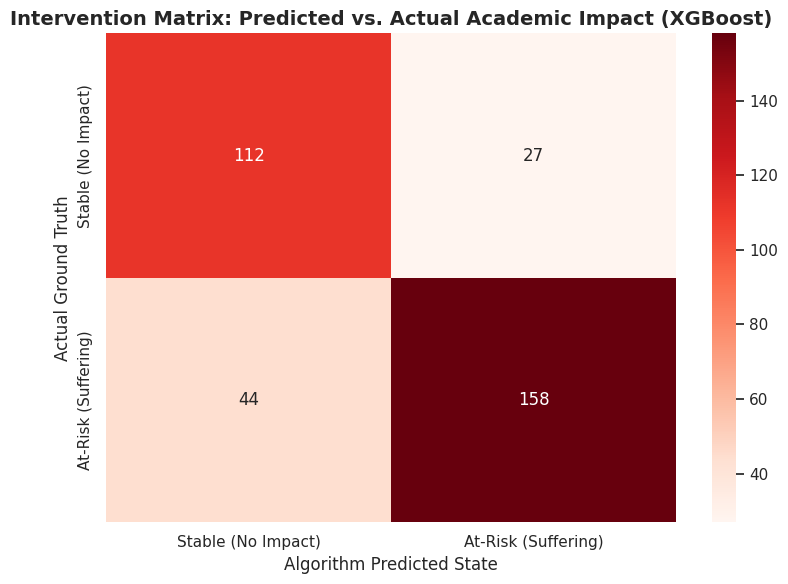


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


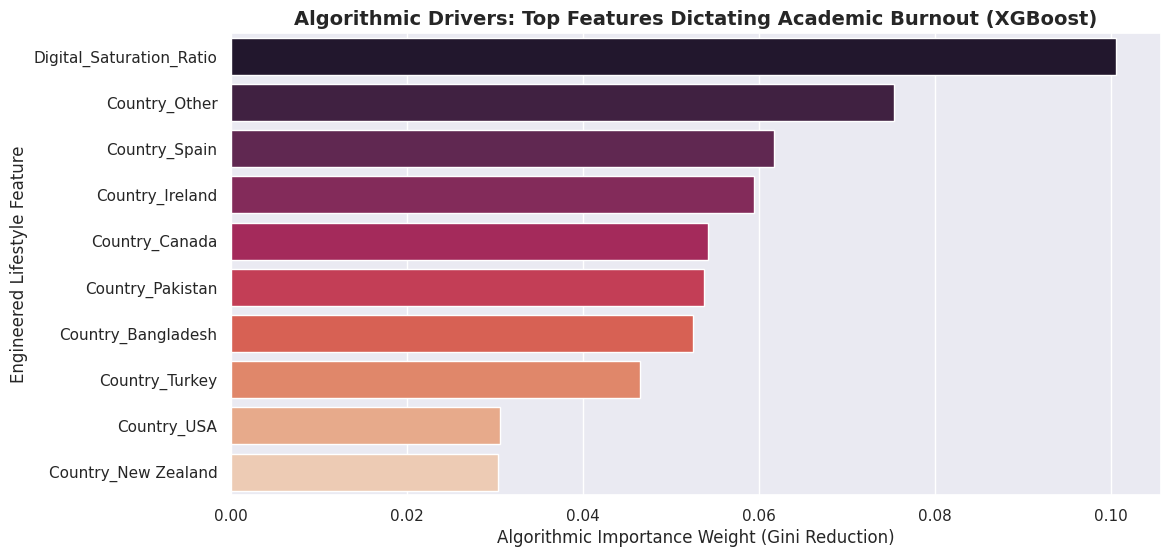

In [21]:
# ==========================================
# PHASE 6: ACADEMIC EARLY-WARNING ENGINE (ML)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# !pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")
# Split: 80% to train the algorithmic rules of student burnout,
# 20% to test true predictive power on unseen students.

X_train, X_test, y_train, y_test = train_test_split(X_adv, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {len(X_train)} students")
print(f"Testing Set: {len(X_test)} students (Strictly Unseen)")


print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")
# 1. Random Forest Classifier
# class_weight='balanced' ensures the algorithm penalizes missing the minority class
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost Classifier
# scale_pos_weight adjusts the gradient descent for class imbalance
scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]) if len(y_train[y_train == 1]) > 0 else 1
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("Both Classification Architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n[{name} Performance Metrics]")
    print(f"   -> Precision: {prec * 100:.2f}% (When flagging a student, how often are they actually struggling?)")
    print(f"   -> Recall:    {rec * 100:.2f}% (Out of ALL struggling students, how many did the system catch?)")
    print(f"   -> F1-Score:  {f1 * 100:.2f}% (Harmonic mean of Precision and Recall)")
    return f1

f1_rf = evaluate_classifier("Random Forest", y_test, rf_preds)
print("-" * 40)
f1_xgb = evaluate_classifier("XGBoost", y_test, xgb_preds)

best_model_name = "XGBoost" if f1_xgb > f1_rf else "Random Forest"
best_preds = xgb_preds if f1_xgb > f1_rf else rf_preds
best_model = xgb_model if f1_xgb > f1_rf else rf_model

print(f"\nThe {best_model_name} mathematically outperformed the alternative in predicting academic degradation.")


print("\n--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---")
# The Confusion Matrix exposes False Positives (wasted interventions) vs False Negatives (ignored students).

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Stable (No Impact)', 'At-Risk (Suffering)'],
            yticklabels=['Stable (No Impact)', 'At-Risk (Suffering)'])
plt.title(f'Intervention Matrix: Predicted vs. Actual Academic Impact ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm Predicted State', fontsize=12)
plt.ylabel('Actual Ground Truth', fontsize=12)
plt.tight_layout()
plt.show()


print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")
# Open the black box: Does screen time actually outweigh sleep deprivation in predicting failure?

importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='rocket')
plt.title(f'Algorithmic Drivers: Top Features Dictating Academic Burnout ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Lifestyle Feature', fontsize=12)
plt.show()

# Thank You